In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

In [12]:
model = joblib.load('../models/rf_model.joblib')
df = pd.read_csv('../data/SPY_features.csv', index_col=0, parse_dates=True)

In [9]:
FEATURES = [
    "price_to_sma10", "price_to_sma20", "sma10_sma20_r",
    "volatility_10", "volatility_20", "rsi_14", "vol_ratio",
    "lag1", "lag2", "lag3", "lag5", "lag10",
]

split  = int(len(df) * 0.80)
X_test = df[FEATURES].iloc[split:]

In [13]:
# Build test dataframe
test = df.iloc[split:].copy()
test["pred"] = model.predict(X_test)

In [14]:
# Signal: UP prediction → long (+1)  |  DOWN → short (-1)
test["signal"] = test["pred"] * 2 - 1

In [16]:
# Strategy daily PnL = today's bet × tomorrow's actual return
test["strat_ret"] = test["signal"] * test["return"].shift(-1)
test.dropna(inplace=True)

In [18]:
# Cumulative equity curves (both start at $1.00)
test["equity_strat"] = (1 + test["strat_ret"]).cumprod()
test["equity_bnh"]   = (1 + test["return"]).cumprod()

In [19]:
ann    = 252  # trading days per year
sharpe = (test["strat_ret"].mean() / test["strat_ret"].std()) * np.sqrt(ann)
eq     = test["equity_strat"]
max_dd = (eq / eq.cummax() - 1).min()

In [20]:
print(f"Strategy final value : {test['equity_strat'].iloc[-1]:.3f}x")
print(f"Buy & Hold final     : {test['equity_bnh'].iloc[-1]:.3f}x")
print(f"Sharpe Ratio         : {sharpe:.3f}   (>0.5 decent  >1.0 strong)")
print(f"Max Drawdown         : {max_dd:.2%}")

Strategy final value : 1.415x
Buy & Hold final     : 1.524x
Sharpe Ratio         : 1.453   (>0.5 decent  >1.0 strong)
Max Drawdown         : -11.51%


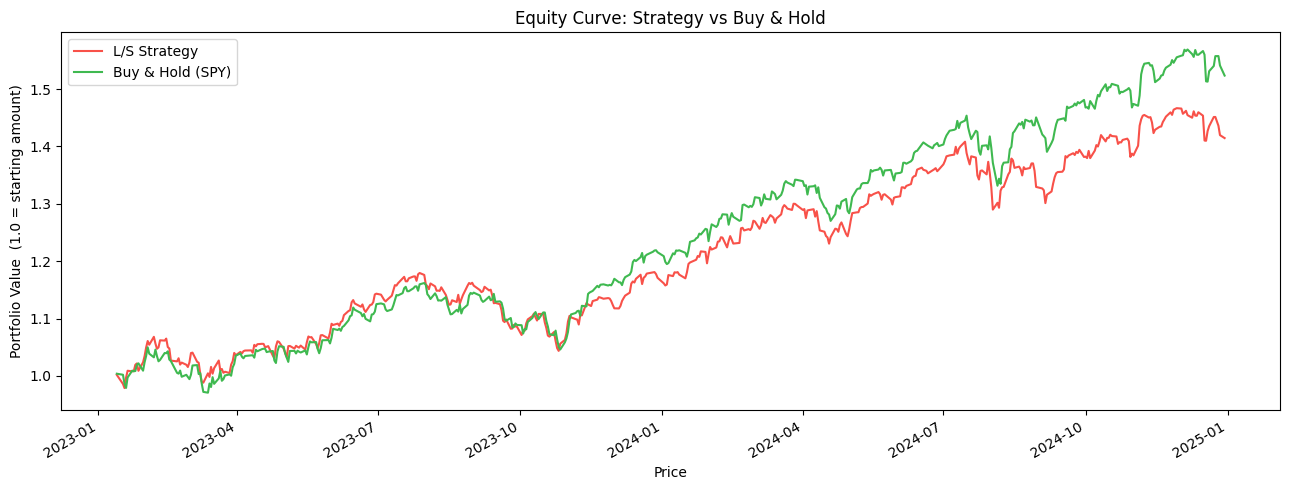

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
test["equity_strat"].plot(ax=ax, label="L/S Strategy", color="#f85149", lw=1.5)
test["equity_bnh"].plot(ax=ax, label="Buy & Hold (SPY)", color="#3fb950", lw=1.5)
ax.set_title("Equity Curve: Strategy vs Buy & Hold")
ax.set_ylabel("Portfolio Value  (1.0 = starting amount)")
ax.legend()
plt.tight_layout()
plt.savefig("equity_curves.png", dpi=120)
plt.show()